# 07 — Robust field-development decision agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/07_robust_field_development_decision_agent.ipynb)

Compare development concepts across subsurface, uptime, price, energy, emissions, and schedule uncertainty.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** concept definitions, uncertainty ensemble, decision
criteria, constraints, and traceable economics. **Outputs:** NPV
distributions, regret, emissions, constraint breaches, and a robust
recommendation.

The screen maximizes a transparent score based on downside value and
regret: $J=P10(NPV)-0.35E[regret]-penalties$.

Deep dive: [offshore concept selection](../../fielddevelopment/offshore_facility_concept_selection_with_neqsim.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
feed = flash_state(NORTHSTAR_GAS, 35.0, 25.0)
kappa = feed["cp_j_kg_k"] / feed["cv_j_kg_k"]
compression_work_kwh_kg = (
    feed["z_factor"]
    * 8.314462618
    * 298.15
    / feed["molar_mass_kg_mol"]
    * kappa
    / (kappa - 1.0)
    * (2.5 ** ((kappa - 1.0) / kappa) - 1.0)
    / 0.76
    / 3.6e6
)
print(f"NeqSim-derived compression intensity={compression_work_kwh_kg:.3f} kWh/kg")


NeqSim-derived compression intensity=0.039 kWh/kg


In [4]:
n_scenarios = 800
recoverable_bsm3 = RNG.lognormal(np.log(92.0), 0.24, n_scenarios)
gas_price_usd_sm3 = np.clip(RNG.normal(0.24, 0.055, n_scenarios), 0.10, 0.42)
carbon_usd_t = np.clip(RNG.normal(145.0, 35.0, n_scenarios), 70.0, 240.0)
schedule_delay_y = RNG.gamma(1.7, 0.32, n_scenarios)
concepts = pd.DataFrame(
    {
        "concept": ["long tieback", "subsea compression", "host upgrade"],
        "capex_busd": [3.5, 5.2, 2.8],
        "capacity_bsm3_y": [6.8, 9.6, 7.7],
        "availability": [0.89, 0.94, 0.86],
        "extra_energy_factor": [1.25, 0.95, 1.10],
        "fixed_opex_busd_y": [0.14, 0.20, 0.12],
    }
)

npv = np.empty((len(concepts), n_scenarios))
emissions = np.empty_like(npv)
annuity_factor = (1.0 - (1.08) ** -18) / 0.08
for index, concept in concepts.iterrows():
    annual_sales = np.minimum(
        recoverable_bsm3 / 18.0,
        concept.capacity_bsm3_y * concept.availability,
    )
    energy_kwh = annual_sales * 1e9 * 0.78 * compression_work_kwh_kg
    emission_mt = energy_kwh * 0.19 / 1e9 * concept.extra_energy_factor
    revenue_busd = annual_sales * 1e9 * gas_price_usd_sm3 / 1e9
    carbon_cost_busd = emission_mt * carbon_usd_t / 1000.0
    delay_discount = (1.08) ** -schedule_delay_y
    npv[index] = (
        (revenue_busd - concept.fixed_opex_busd_y - carbon_cost_busd)
        * annuity_factor
        * delay_discount
        - concept.capex_busd
    )
    emissions[index] = emission_mt


In [5]:
best_by_scenario = npv.max(axis=0)
rows = []
for index, concept in concepts.iterrows():
    concept_npv = npv[index]
    regret = best_by_scenario - concept_npv
    p10 = np.quantile(concept_npv, 0.10)
    expected_regret = regret.mean()
    emissions_p90 = np.quantile(emissions[index], 0.90)
    penalty = 2.0 * max(emissions_p90 - 0.25, 0.0)
    rows.append(
        {
            "concept": concept.concept,
            "npv_p10_busd": p10,
            "npv_mean_busd": concept_npv.mean(),
            "expected_regret_busd": expected_regret,
            "emissions_p90_mt_y": emissions_p90,
            "robust_score": p10 - 0.35 * expected_regret - penalty,
        }
    )
decision = pd.DataFrame(rows).sort_values("robust_score", ascending=False)
display(decision)
selected = decision.iloc[0].concept
print(f"Robust recommendation: {selected}")


Robust recommendation: host upgrade


,concept,npv_p10_busd,npv_mean_busd,expected_regret_busd,emissions_p90_mt_y,robust_score
2,host upgrade,2.759649,6.975132,0.023827,0.042483,2.751310
0,long tieback,1.842993,5.888717,1.110243,0.044121,1.454409
1,subsea compression,-0.345490,4.094575,2.904385,0.038263,-1.362025


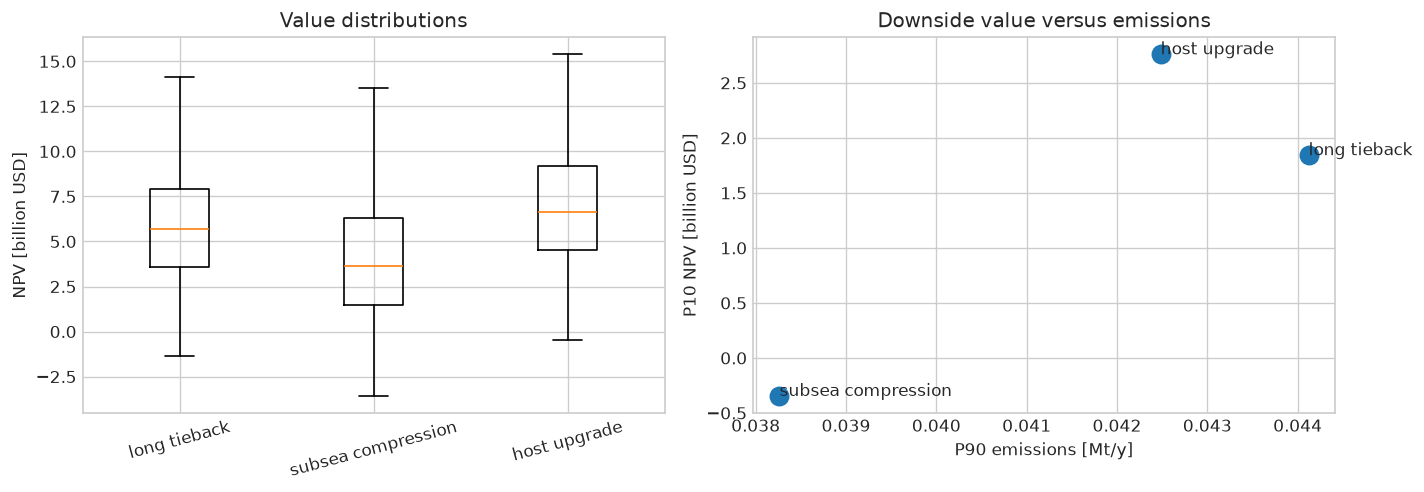

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].boxplot(npv.T, tick_labels=concepts.concept, showfliers=False)
axes[0].set(ylabel="NPV [billion USD]", title="Value distributions")
axes[0].tick_params(axis="x", rotation=15)
axes[1].scatter(
    decision.emissions_p90_mt_y,
    decision.npv_p10_busd,
    s=120,
)
for _, row in decision.iterrows():
    axes[1].annotate(row.concept, (row.emissions_p90_mt_y, row.npv_p10_busd))
axes[1].set(
    xlabel="P90 emissions [Mt/y]",
    ylabel="P10 NPV [billion USD]",
    title="Downside value versus emissions",
)
plt.tight_layout()
plt.show()


In [7]:
assert selected in set(concepts.concept)
assert decision.robust_score.is_monotonic_decreasing
assert np.all(np.isfinite(npv))
print("VALIDATION PASSED")
print("Recommendation is conditional on the declared ensemble and weights.")


VALIDATION PASSED
Recommendation is conditional on the declared ensemble and weights.


## Interpretation and limits

The recommendation emphasizes downside value and regret rather than a
single deterministic NPV. Results are decision-framing evidence, not
sanction economics: fiscal terms, schedule correlations, market
constraints, emissions accounting, and concept maturation remain.
